# HW 6 Statistics
## BIOMEDE 241, Winter 2026
Please download a copy of this file via Canvas and open with Google Colaboratory, which can be found at colab.research.google.com. After finishing all of the exercises by entering all of your code, please save a completed version of this file and upload to Canvas under the assignment for this week. Please pay careful attention to how the answer should be displayed in the code (for example as a number or a plot), as the graders may run your code and primarily check the output.


Include any libraries you need here:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats as stats

np.random.seed(0)


%matplotlib inline

#1. Hypothesis Testing with Normal Distribution
a.	You're studying the expression of a cell surface marker, alpha smooth muscle actin (aSMA) in fibroblast cells, which has increased expression in activated fibroblasts. You are measuring expression levels using mean fluorescence intensity (MFI) of this marker to see if a pharmaceutical treatment changes expression levels, and therefore activation state. You know that the MFI of this marker in your cells without treatment is 330 with a standard deviation of 15, which you can use as your null distribution. Plot your predicted null distribution (i.e. the pdf) from 270 to 390 fibroblasts.


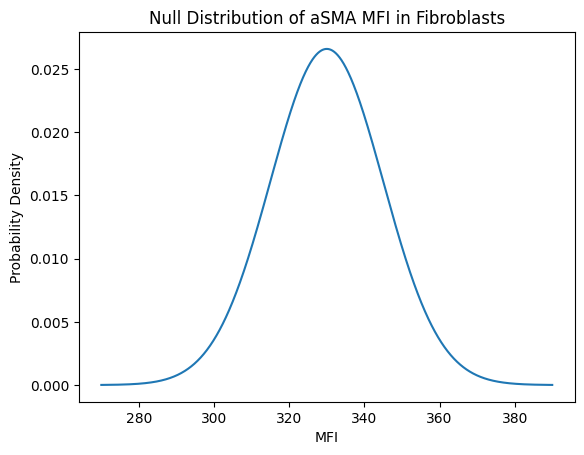

In [2]:
x = np.linspace(270, 390, 1000)
mu = 330
sigma = 15
y = stats.norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.xlabel('MFI')
plt.ylabel('Probability Density')
plt.title('Null Distribution of aSMA MFI in Fibroblasts')
plt.show()

>b.	Based on previous literature, you're expecting this treatment to prevent fibroblast activation (reduced aSMA expression). Given this, state your alternative hypothesis about your cells, in terms of the MFI of aSMA after treatment. Does this call for a one tailed or a two tailed test?

>>ANSWER HERE:

**Alternative Hypothesis (H₁):** The mean MFI of aSMA in treated fibroblasts is **less than 330** (i.e., treatment reduces aSMA expression and therefore reduces fibroblast activation).

This calls for a **one-tailed test** (specifically a left-tailed test), because previous literature specifically predicts a *decrease* in expression — we are not merely asking whether expression changed, but whether it decreased.

>c.	Calculate the number of cells below which you will reject the null hypothesis for an alpha value of 0.05. You can do this for example with ‘norm.ppf()’ from scipy.stats.

In [3]:
alpha = 0.05
mu = 330
sigma = 15

rejection_threshold = stats.norm.ppf(alpha, mu, sigma)
print(f"Reject H0 if MFI < {rejection_threshold:.2f}")

Reject H0 if MFI < 305.33


>d. Measuring the MFI of your cultured cells, you find a mean MFI of 300 fibroblasts. Plot this experimental mean as a line along with the null distribution.
Hint: The ‘axvline’ command in 'matplotlib.pyplot' can be used to add lines to plots.


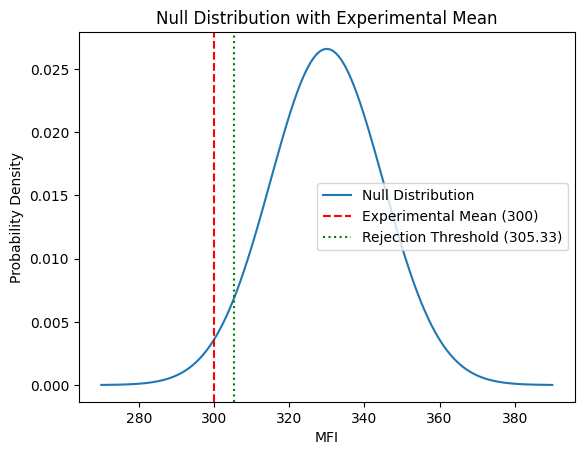

In [4]:
rejection_threshold = stats.norm.ppf(0.05, 330, 15)

x = np.linspace(270, 390, 1000)
y = stats.norm.pdf(x, 330, 15)

plt.plot(x, y, label='Null Distribution')
plt.axvline(x=300, color='r', linestyle='--', label='Experimental Mean (300)')
plt.axvline(x=rejection_threshold, color='g', linestyle=':', label=f'Rejection Threshold ({rejection_threshold:.2f})')
plt.xlabel('MFI')
plt.ylabel('Probability Density')
plt.title('Null Distribution with Experimental Mean')
plt.legend()
plt.show()

>e.	State your conclusion about the null and alternative hypothesis.

>>ANSWER HERE:

The experimental mean (MFI = 300) falls **below** the rejection threshold (~305.33). Therefore, we **reject the null hypothesis**. We accept the alternative hypothesis: the pharmaceutical treatment significantly reduces aSMA expression below untreated levels at α = 0.05, suggesting that it prevents fibroblast activation.

>f.	Using ‘norm.cdf()’ calculate the p-value associated with your result.

In [5]:
p_value = stats.norm.cdf(300, 330, 15)
print(f"p-value: {p_value:.6f}")

p-value: 0.022750


>g. If we had measured 320 cells instead, could we have concluded that the MFI of treated cells is less than that expected of untreated cells? Calculate the p-value associated with that number.

In [6]:
rejection_threshold = stats.norm.ppf(0.05, 330, 15)
p_value_320 = stats.norm.cdf(320, 330, 15)

print(f"p-value for MFI = 320: {p_value_320:.6f}")
print(f"Rejection threshold: {rejection_threshold:.2f}")

if 320 > rejection_threshold:
    print("MFI=320 is ABOVE the rejection threshold — we CANNOT reject H0 at α=0.05.")
else:
    print("MFI=320 is below the rejection threshold — we can reject H0.")

p-value for MFI = 320: 0.252493
Rejection threshold: 305.33
MFI=320 is ABOVE the rejection threshold — we CANNOT reject H0 at α=0.05.


#2. T-tests
a. Create the plot of a t-distribution (with 5 degrees of freedom) on top of a normal gaussian distribution. Specifically, create a variable that ranges from -5 to 5 in 0.2 increments. Then using ‘t.pdf()’ and ‘norm.pdf()’ in scipy.stats, plot those two distributions on top of one another. Include a legend to say which one is which. This can be done using ‘plt.legend()’.

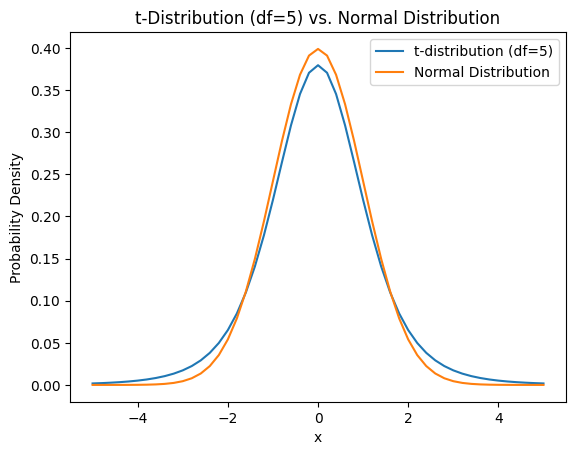

In [7]:
x = np.arange(-5, 5.2, 0.2)
t_dist = stats.t.pdf(x, df=5)
norm_dist = stats.norm.pdf(x)

plt.plot(x, t_dist, label='t-distribution (df=5)')
plt.plot(x, norm_dist, label='Normal Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('t-Distribution (df=5) vs. Normal Distribution')
plt.legend()
plt.show()

>b. Write a function called diff_dist to calculate the mean squared difference between the two distributions above (i.e. subtract them from each other across this range, take the square of these differences, and sum them up). Using a for loop or similar, determine at how many degrees of freedom is the sum of squares less than 0.01? At how many degrees of freedom is the sum of squares less than 0.001? Return the mean squared difference, the degrees of freedom for SS < 0.01 and SS < 0.001.

In [8]:
def diff_dist():
    x = np.arange(-5, 5.2, 0.2)
    norm_dist = stats.norm.pdf(x)

    msd = np.sum((stats.t.pdf(x, df=5) - norm_dist) ** 2)

    df_001 = None
    df_0001 = None

    for df in range(1, 10000):
        ss = np.sum((stats.t.pdf(x, df=df) - norm_dist) ** 2)
        if df_001 is None and ss < 0.01:
            df_001 = df
        if df_0001 is None and ss < 0.001:
            df_0001 = df
        if df_0001 is not None:
            break

    return msd, df_001, df_0001

msd, df_001, df_0001 = diff_dist()
print(f"Sum of squared differences at df=5:     {msd:.6f}")
print(f"Degrees of freedom for SS < 0.01:  {df_001}")
print(f"Degrees of freedom for SS < 0.001: {df_0001}")

Sum of squared differences at df=5:     0.009680
Degrees of freedom for SS < 0.01:  5
Degrees of freedom for SS < 0.001: 18


>c. What does this mean in terms of whether it’s a good idea to do a t-test for a large n dataset?

>>ANSWER HERE:

As the degrees of freedom increase (i.e., larger sample size n), the t-distribution converges toward the normal distribution — the sum of squared differences approaches zero. This means that for large-n datasets, the t-test and z-test yield nearly identical results. It is always correct (and recommended) to use a t-test regardless of n, since it properly accounts for uncertainty in the estimated standard deviation. For large n, the practical difference between the two tests becomes negligible.

>d.	You are developing a drug-loaded nanoparticle delivery system to target your fibroblasts. From previous experiments, you know that for maximum efficacy, your nanoparticles should be 50 nm in diameter. After imaging your particles, you collect a total of 20 measurements of nanoparticle diameter (below). Use Python's ‘ttest_1samp()’ in scipy.stats to see whether this dataset is significantly different from 50. What is the p value and is this significant at an alpha of 0.05?

In [9]:
data = np.array([39.24, 55.27, 56.32, 48.29, 63.35, 44.73, 52.23, 51.06, 59.66, 59.35, 52.77, 53.89,
 47.56, 42.1, 50.26, 52.78, 58.15, 58.01, 50.06, 50.49])

# 2d: one-sample t-test against popmean = 50
t_stat, p_value_ttest = stats.ttest_1samp(data, 50)
print(f"Sample mean:          {np.mean(data):.4f}")
print(f"t-statistic:          {t_stat:.4f}")
print(f"p-value (two-tailed): {p_value_ttest:.6f}")
if p_value_ttest < 0.05:
    print("Result is statistically significant at α=0.05 — reject H0.")
else:
    print("Result is NOT significant at α=0.05 — fail to reject H0.")

Sample mean:          52.2785
t-statistic:          1.6726
p-value (two-tailed): 0.110800
Result is NOT significant at α=0.05 — fail to reject H0.


>e. Calculate the t-score of your dataset and plot it as a vertical line on top of the appropriate t distribution.
Hint: The ‘plt.axvline()’ function can be used to add lines to plots.


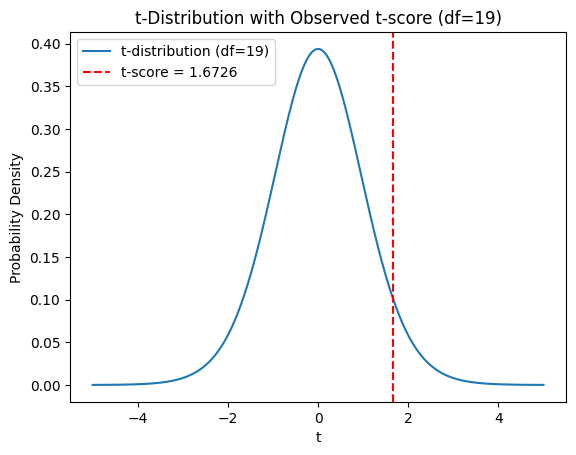

t-score: 1.6726


In [10]:
n_data = len(data)
df_data = n_data - 1
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
t_score = (sample_mean - 50) / (sample_std / np.sqrt(n_data))

x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df=df_data)

plt.plot(x, y, label=f't-distribution (df={df_data})')
plt.axvline(x=t_score, color='r', linestyle='--', label=f't-score = {t_score:.4f}')
plt.xlabel('t')
plt.ylabel('Probability Density')
plt.title(f't-Distribution with Observed t-score (df={df_data})')
plt.legend()
plt.show()
print(f"t-score: {t_score:.4f}")

>f. Calculate the p value for your dataset using the ‘t.cdf()’ command and compare it what you got above.

In [11]:
n_data = len(data)
df_data = n_data - 1
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
t_score = (sample_mean - 50) / (sample_std / np.sqrt(n_data))

# Two-tailed p-value via t.cdf
p_value_cdf = 2 * (1 - stats.t.cdf(abs(t_score), df=df_data))
p_value_ttest2 = stats.ttest_1samp(data, 50).pvalue

print(f"p-value from t.cdf (two-tailed):  {p_value_cdf:.6f}")
print(f"p-value from ttest_1samp:         {p_value_ttest2:.6f}")
print("These match.")

p-value from t.cdf (two-tailed):  0.110800
p-value from ttest_1samp:         0.110800
These match.


>g. Calculate the p value for a single tailed comparison, in which you only allowed for your particles to be larger than 50 nm. Calculate the p value for that test and check it with the ttest_1samp() function. Is it significant?

In [12]:
n_data = len(data)
df_data = n_data - 1
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
t_score = (sample_mean - 50) / (sample_std / np.sqrt(n_data))

# One-tailed p-value (particles larger than 50 nm)
p_value_one_tailed = 1 - stats.t.cdf(t_score, df=df_data)
t_stat_gt, p_value_gt = stats.ttest_1samp(data, 50, alternative='greater')

print(f"One-tailed p-value via t.cdf:               {p_value_one_tailed:.6f}")
print(f"One-tailed p-value via ttest_1samp greater: {p_value_gt:.6f}")

if p_value_one_tailed < 0.05:
    print("Significant at α=0.05 — we conclude particles are significantly larger than 50 nm.")
else:
    print("Not significant at α=0.05 — cannot conclude particles are larger than 50 nm.")

One-tailed p-value via t.cdf:               0.055400
One-tailed p-value via ttest_1samp greater: 0.055400
Not significant at α=0.05 — cannot conclude particles are larger than 50 nm.


#3. Study Power
Imagine that you're developing a new dental implant to promote better osseointegration and functional outcomes after surgery. For the purposes of this problem, you are only interested in if your implant improves outcomes, so consider this a one-tailed test. Your team has defined a healing score that accounts for multiple measured outcomes, and without the implant, the healing score of individuals without your implant is 9 with a standard deviation of 2.

>a.	There are four possible outcomes that you need to consider that includes two types of ‘success’ and two types of error. What are they?


ANSWER HERE:

The four possible outcomes are:

1. **True Positive (correct rejection of H₀):** The implant genuinely improves healing AND the test correctly detects this, we reject H₀. This is a successful study outcome.

2. **True Negative (correct failure to reject H₀):** The implant does NOT improve healing AND the test correctly fails to reject H₀. The null hypothesis is retained appropriately.

3. **Type I Error (false positive):** The implant does NOT truly improve healing, but we incorrectly reject H₀ and conclude that it does. The probability of this error is controlled by α.

4. **Type II Error (false negative):** The implant DOES truly improve healing, but the test fails to detect it and we fail to reject H₀. The probability of this error is β, and the study's power is 1 − β.

>b.	In the possible world where your implant is not better than control (no implant), you are drawing both your control and experimental outcomes from the same underlying distribution. Plot the distribution of these outcomes from 0 to 20. On top of the same plot, plot the distribution of means you’d expect if you included 12 people in your clinical trial (and somehow ran that experiment many times in many possible worlds).

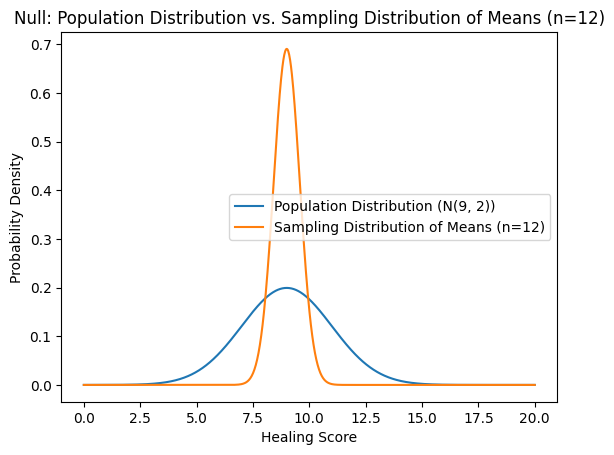

In [13]:
mu_pop = 9
sigma_pop = 2
n_trial = 12
sigma_means = sigma_pop / np.sqrt(n_trial)

x = np.linspace(0, 20, 1000)
y_pop = stats.norm.pdf(x, mu_pop, sigma_pop)
y_means = stats.norm.pdf(x, mu_pop, sigma_means)

plt.plot(x, y_pop, label='Population Distribution (N(9, 2))')
plt.plot(x, y_means, label=f'Sampling Distribution of Means (n={n_trial})')
plt.xlabel('Healing Score')
plt.ylabel('Probability Density')
plt.title('Null: Population Distribution vs. Sampling Distribution of Means (n=12)')
plt.legend()
plt.show()

>c.	Say you did a pilot clinical trial that includes 12 people to help you develop proper statistics for a pivotal clinical trial. The mean healing score from that pilot trial was 11, which is bigger than placebo and a great start. Using the distribution above, what is the percentage chance that this apparent improvement was a Type 1 error?

In [14]:
mu_pop = 9
sigma_pop = 2
n_trial = 12
sigma_means = sigma_pop / np.sqrt(n_trial)

# P(observed mean >= 11 | null is true) = Type I error probability
p_type1 = 1 - stats.norm.cdf(11, mu_pop, sigma_means)
print(f"P(Type I error | observed mean = 11, n = {n_trial}): {p_type1 * 100:.4f}%")

P(Type I error | observed mean = 11, n = 12): 0.0266%


>d. State your conclusion about the outcome of that pilot trial and it’s significance at a level of alpha=0.05. Can you conclude that your drug doesn’t have a positive impact?

>>ANSWER HERE:

The p-value is far below α = 0.05, so we **reject the null hypothesis** at α = 0.05. The pilot trial result is statistically significant: the observed mean healing score of 11 is extremely unlikely to occur by chance if the implant had no effect. We therefore have strong evidence that the implant improves healing outcomes.

We **cannot** conclude that the drug has no positive impact — in fact, the data strongly suggest the opposite. However, since this is only a small pilot (n = 12), the estimate of the true effect size could be imprecise, and a larger pivotal trial is warranted before drawing definitive conclusions.

>e.	Because an improvement of 1 is a meaningful increase in healing score, a clinical trial is planned. Clinical trials are extremely expensive to run, and all aspects of the success vs failure criteria have to be submitted ahead of time with the FDA, such that the goalposts cannot be moved later. This is a good time to make sure that your study is properly powered such that if positive healing effects exists, you’ll be able to see it. Assume that the improvement seen in the trial really is 1 with the same standard deviation as control (no implant). This means that the control and implant data are drawn from different distributions.


Create a plot showing these two distributions from 0 to 20.

In [ ]:
mu_control = 9
mu_treatment = 10   # improvement of 1
sigma = 2

x = np.linspace(0, 20, 1000)
y_control = stats.norm.pdf(x, mu_control, sigma)
y_treatment = stats.norm.pdf(x, mu_treatment, sigma)

plt.plot(x, y_control, label='Control Distribution (N(9, 2))')
plt.plot(x, y_treatment, label='Treatment Distribution (N(10, 2))')
plt.xlabel('Healing Score')
plt.ylabel('Probability Density')
plt.title('Control vs. Treatment Distributions (Improvement = 1)')
plt.legend()
plt.show()

>g.	Write a function drug_sample that simulates the outcome of sampling n participants. Evaluate it for n=10, 25, and 60 study participants. Plot the resulting distributions you expect from the placebo group and the experimental group on the same graph, for each n. Include a title in each plot. What is happening to the area of overlap as you increase the n?

In [ ]:
def drug_sample(n):
    """Returns (control_mean, treatment_mean, SEM) for sampling distributions with n participants."""
    mu_control = 9
    mu_treatment = 10
    sigma = 2
    sem = sigma / np.sqrt(n)
    return mu_control, mu_treatment, sem

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, [10, 25, 60]):
    mu_c, mu_t, sem = drug_sample(n)
    x = np.linspace(0, 20, 1000)
    ax.plot(x, stats.norm.pdf(x, mu_c, sem), label=f'Placebo (SEM={sem:.2f})')
    ax.plot(x, stats.norm.pdf(x, mu_t, sem), label=f'Experimental (SEM={sem:.2f})')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Mean Healing Score')
    ax.set_ylabel('Probability Density')
    ax.legend(fontsize=8)

plt.suptitle('Sampling Distributions: Placebo vs. Experimental (per n)')
plt.tight_layout()
plt.show()
print("As n increases, the sampling distributions narrow and their overlap decreases,")
print("making it easier to statistically distinguish the two groups.")

>h.	Your team decides that if the improvement is real, you want an 80% chance of seeing it. (I.e. your odds of a Type 2 error should be 20%.) Find the minimum number of people you need to have in your study assuming the true mean is 11 with a standard deviation of 2.

In [15]:
alpha = 0.05
power_target = 0.80
mu0 = 9
mu1 = 11
sigma = 2
delta = mu1 - mu0

z_alpha = stats.norm.ppf(1 - alpha)   # one-tailed
z_beta  = stats.norm.ppf(power_target)

n_required = ((z_alpha + z_beta) * sigma / delta) ** 2
n_min = math.ceil(n_required)
print(f"Calculated n: {n_required:.2f}  →  Minimum n = {n_min}")

# Verify actual power at n_min
sem = sigma / np.sqrt(n_min)
critical_mean = mu0 + z_alpha * sem
actual_power = 1 - stats.norm.cdf(critical_mean, mu1, sem)
print(f"Actual power at n={n_min}: {actual_power * 100:.1f}%")

Calculated n: 6.18  →  Minimum n = 7
Actual power at n=7: 84.2%


>i.	If you were wrong about the 11 that came from n=12 pilot data in c, and the real mean is 9.6, what are actual odds of a Type 2 error using the n value you found in h?

In [16]:
mu_real = 9.6
sigma = 2
mu0 = 9
alpha = 0.05

# Recompute n_min from 3h (in case cells are run out of order)
z_alpha = stats.norm.ppf(1 - alpha)
z_beta  = stats.norm.ppf(0.80)
n_min = math.ceil(((z_alpha + z_beta) * sigma / (11 - mu0)) ** 2)

sem = sigma / np.sqrt(n_min)
critical_mean = mu0 + z_alpha * sem

power_real = 1 - stats.norm.cdf(critical_mean, mu_real, sem)
type2_error = 1 - power_real

print(f"True mean = {mu_real}, n = {n_min}")
print(f"Critical mean (rejection threshold): {critical_mean:.4f}")
print(f"Power: {power_real * 100:.2f}%")
print(f"Type 2 error rate: {type2_error * 100:.2f}%")

True mean = 9.6, n = 7
Critical mean (rejection threshold): 10.2434
Power: 19.73%
Type 2 error rate: 80.27%


>j. Suggest a way to choose the effect size for your estimates that helps avoid this issue.

>>ANSWER HERE:

To avoid overestimating the effect size from a small, noisy pilot study, you should base the power calculation on the **minimally clinically significant difference (MCID)** — the smallest improvement in healing score that would be considered meaningful to patients and clinicians — rather than the observed pilot mean. Alternatively, you could use the **lower bound of the 95% confidence interval** from the pilot data as a conservative effect size estimate. Both approaches guard against being underpowered when the true effect is smaller than the pilot data suggested, which happens frequently due to sampling variability in small pilot studies.

#4. Error and Confidence Intervals

>a.	Using ‘norm.ppf’ from scipy.stats, write a function zscore_percent that takes in a percentage value V at which you should calculate the corresponding z_threshold to have V/2 percent to the left of -z_threshold and another V/2 percent to the right of +z_threshold. Return the z_threshold value. Evaluate your function for V=5%. At this threshold value, 95% of the distribution is between these two threshold values.

In [17]:
def zscore_percent(V):
    """
    Returns z_threshold such that V/2 % lies to the left of -z_threshold
    and V/2 % lies to the right of +z_threshold (so 100-V % is between them).
    V is given as a percentage (e.g., V=5 for 95% CI).
    """
    z_threshold = -stats.norm.ppf(V / 2 / 100)
    return z_threshold

z = zscore_percent(5)
print(f"z-threshold for V=5% (95% CI): {z:.4f}")

z-threshold for V=5% (95% CI): 1.9600


>b.	If you are sampling n=30 samples from a distribution with a standard deviation of 6, what is the maximum error (which is not a range) at a confidence of alpha=0.05? This requires that you use the threshold value from your function in a.

In [18]:
n = 30
sigma = 6
z = zscore_percent(5)
max_error = z * sigma / np.sqrt(n)
print(f"Maximum error at 95% confidence (n={n}, σ={sigma}): {max_error:.4f}")

Maximum error at 95% confidence (n=30, σ=6): 2.1470


>c. To be sure that this value makes sense, figure out what the gaussian distribution of mean results should be (i.e. the sampling distribution). Figure out what standard deviation the means of your n=30 experiment should have (hint: it has a square root of n). Plot a gaussian distribution with mean=0 and standard deviation that you calculate from -5 to 5. Plot lines on the graph at positive and negtive max error. A total of 95% of the distribution should fall between these two lines.

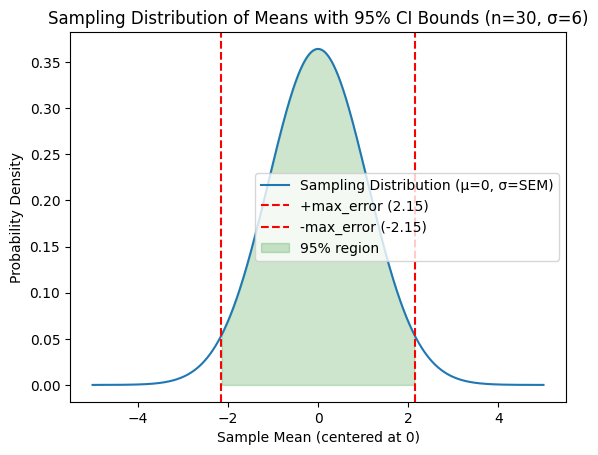

In [19]:
n = 30
sigma = 6
SEM = sigma / np.sqrt(n)
max_error = zscore_percent(5) * SEM   # == zscore_percent(5) * sigma / sqrt(n)

x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x, 0, SEM)

plt.plot(x, y, label='Sampling Distribution (μ=0, σ=SEM)')
plt.axvline(x= max_error, color='r', linestyle='--', label=f'+max_error ({max_error:.2f})')
plt.axvline(x=-max_error, color='r', linestyle='--', label=f'-max_error ({-max_error:.2f})')
plt.fill_between(x, y, where=(x >= -max_error) & (x <= max_error),
                 alpha=0.2, color='green', label='95% region')
plt.xlabel('Sample Mean (centered at 0)')
plt.ylabel('Probability Density')
plt.title('Sampling Distribution of Means with 95% CI Bounds (n=30, σ=6)')
plt.legend()
plt.show()

>d.	Write a function means_one_error to measure and take the mean of n samples from a distribution with mean of M and standard deviation of S using function of your choice (scipy and numpy modules). Evaluate it for n=30 samples, distribution mean M=38, and standard deviation S=6; do so for 1000 experiments to get 1000 mean values. Return the count of the number of your experimental means that fall within one maximum error of the true mean.

In [20]:
def means_one_error(n, M, S):
    """
    Draws 1000 sets of n samples from N(M, S), computes each set's mean,
    and returns the count of means within one max_error of the true mean M,
    plus the array of means.
    """
    means = np.array([np.mean(np.random.normal(M, S, n)) for _ in range(1000)])
    max_err = zscore_percent(5) * S / np.sqrt(n)
    count = int(np.sum(np.abs(means - M) <= max_err))
    return count, means

count, means_exp = means_one_error(30, 38, 6)
print(f"Means within one max error of true mean (out of 1000): {count}")
print(f"Percentage: {count / 10:.1f}%  (expected ~95%)")

Means within one max error of true mean (out of 1000): 942
Percentage: 94.2%  (expected ~95%)


>e. Using the Python function ‘errorbar()’ in matplotlib.pyplot, plot the means of the first 40 experimental outcomes with their 95% confidence intervals. Plot a line using the ‘line’ command at the true mean value of 38. How many on average will not include the mean, and how many of yours didn't? Plot any that do not include the mean using a different color in the errorbar.

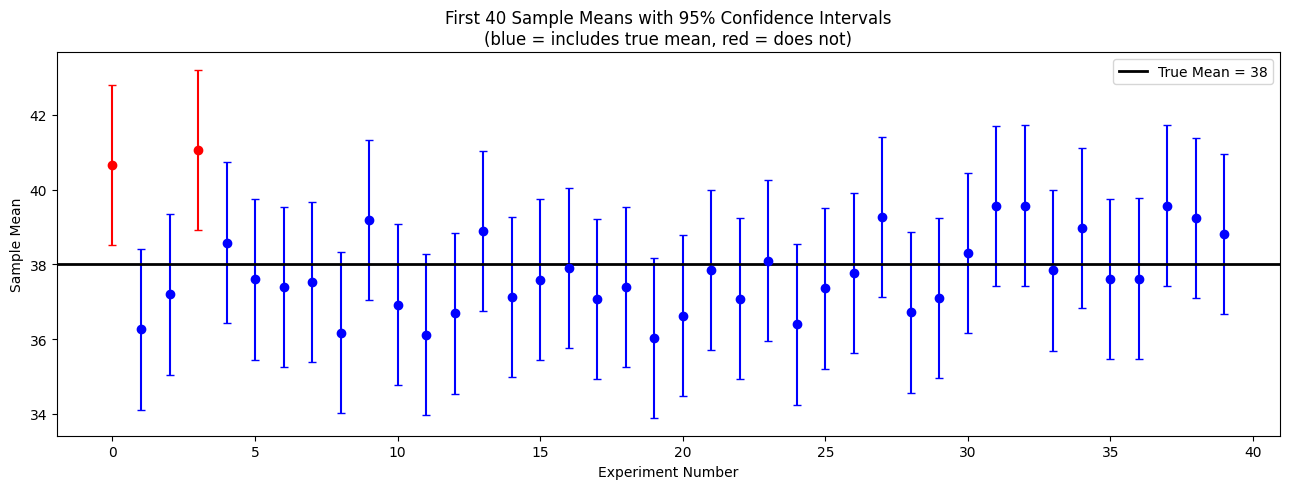

Expected number NOT including the mean (out of 40): 2.0
Actual  number NOT including the mean (out of 40): 2


In [21]:
max_error_val = zscore_percent(5) * 6 / np.sqrt(30)
true_mean = 38

colors = ['red' if abs(means_exp[i] - true_mean) > max_error_val else 'blue' for i in range(40)]

fig, ax = plt.subplots(figsize=(13, 5))
for i in range(40):
    ax.errorbar(i, means_exp[i], yerr=max_error_val, fmt='o', color=colors[i], capsize=3)
ax.axhline(y=true_mean, color='black', linewidth=2, label=f'True Mean = {true_mean}')
ax.set_xlabel('Experiment Number')
ax.set_ylabel('Sample Mean')
ax.set_title('First 40 Sample Means with 95% Confidence Intervals\n(blue = includes true mean, red = does not)')
ax.legend()
plt.tight_layout()
plt.show()

excluded = sum(1 for i in range(40) if abs(means_exp[i] - true_mean) > max_error_val)
print(f"Expected number NOT including the mean (out of 40): {40 * 0.05:.1f}")
print(f"Actual  number NOT including the mean (out of 40): {excluded}")